
# Actividad: clasificación binaria con PyTorch y entropía cruzada

Implementar un modelo de **regresión logística** usando PyTorch y gradientes automáticos.

En esta actividad se entrega una base de datos sintética linealmente separable, las librerías necesarias y algunas funciones auxiliares. Deben completar el entrenamiento, la frontera de decisión y el análisis de resultados.

El modelo es:

$$
z = \phi_0 + \phi_1 x_1 + \phi_2 x_2
$$

$$
\hat{y} = p(y=1\mid \mathbf{x}) = \sigma(z)
$$

donde:

$$
\sigma(z)=\frac{1}{1+\exp(-z)}.
$$

La función de costo será la entropía cruzada binaria:

$$
\mathcal{L}(\boldsymbol{\phi})
=
-\frac{1}{N}
\sum_{n=1}^{N}
\left[
y_n\log(\hat{y}_n)
+
(1-y_n)\log(1-\hat{y}_n)
\right].
$$



## 1. Librerías


In [4]:

import torch
import matplotlib.pyplot as plt

torch.manual_seed(42)



## 2. Base de datos sintética lineal

La siguiente base de datos tiene dos clases aproximadamente separables por una frontera lineal.

La clase 0 se concentra alrededor de $(-2,-2)$ y la clase 1 alrededor de $(2,2)$.


In [5]:

# Número total de muestras
N = 120

# Clase 0
X0 = torch.randn(N//2, 2) + torch.tensor([-2.0, -2.0])

# Clase 1
X1 = torch.randn(N//2, 2) + torch.tensor([2.0, 2.0])

# Matriz de datos
X = torch.cat([X0, X1], dim=0)

# Etiquetas
y = torch.cat([
    torch.zeros(N//2),
    torch.ones(N//2)
], dim=0)

print("Dimensión de X:", X.shape)
print("Dimensión de y:", y.shape)


Dimensión de X: torch.Size([120, 2])
Dimensión de y: torch.Size([120])



## 3. Función auxiliar para graficar la función de costo

Esta función recibe una lista con los valores de la pérdida durante el entrenamiento y grafica su evolución.


In [6]:

def plot_loss(loss_history):
    plt.figure(figsize=(6, 4))
    plt.plot(loss_history)
    plt.xlabel("Iteración")
    plt.ylabel("Función de costo")
    plt.title("Evolución de la función de costo")
    plt.grid(True)
    plt.show()



## 4. Función auxiliar para visualizar los datos

Esta función permite graficar las dos clases. Más adelante puede modificarse para incluir la frontera de decisión.


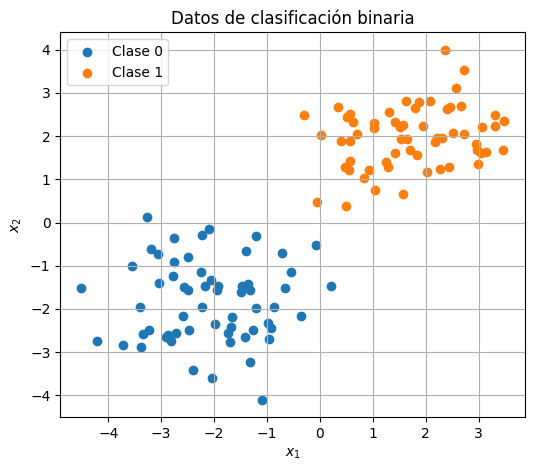

In [7]:

def plot_data(X, y):
    plt.figure(figsize=(6, 5))
    plt.scatter(X[y == 0, 0], X[y == 0, 1], label="Clase 0")
    plt.scatter(X[y == 1, 0], X[y == 1, 1], label="Clase 1")
    plt.xlabel(r"$x_1$")
    plt.ylabel(r"$x_2$")
    plt.title("Datos de clasificación binaria")
    plt.grid(True)
    plt.legend()
    plt.show()

plot_data(X, y)



## 5. Inicialización de parámetros

Inicialice los parámetros:

$$
\phi_0,\phi_1,\phi_2
$$

como tensores entrenables con `requires_grad=True`.


In [5]:

phi_0 = torch.tensor([0.0], requires_grad=True)
phi_1 = torch.tensor([0.0], requires_grad=True)
phi_2 = torch.tensor([0.0], requires_grad=True)

print("phi_0 inicial:", phi_0.item())
print("phi_1 inicial:", phi_1.item())
print("phi_2 inicial:", phi_2.item())


phi_0 inicial: 0.0
phi_1 inicial: 0.0
phi_2 inicial: 0.0



## 6. Modelo logístico

Complete el cálculo de:

$$
z = \phi_0 + \phi_1 x_1 + \phi_2 x_2
$$

$$
\hat{y}=\sigma(z).
$$

Use `torch.sigmoid`.


In [6]:
# TODO: completar el cálculo de z
z = phi_0 + phi_1 * X[:, 0] + phi_2 * X[:, 1]

# TODO: completar el cálculo de y_hat
y_hat = torch.sigmoid(z)

# Sugerencia para verificar:
print(y_hat[:10])


tensor([0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000,
        0.5000], grad_fn=<SliceBackward0>)



## 7. Entropía cruzada binaria

Complete el cálculo de la función de costo:

$$
\mathcal{L}
=
-\frac{1}{N}
\sum_{n=1}^{N}
\left[
y_n\log(\hat{y}_n)
+
(1-y_n)\log(1-\hat{y}_n)
\right].
$$

Use `torch.log`.


In [7]:

eps = 1e-8

# TODO: calcular la entropía cruzada binaria
loss = -torch.mean(y * torch.log(y_hat + eps) + (1 - y) * torch.log(1 - y_hat + eps))

# Sugerencia para verificar:
print("Pérdida inicial:", loss.item())


Pérdida inicial: 0.6931472420692444



## 8. Entrenamiento con gradiente descendente

Complete el ciclo de entrenamiento.

En cada iteración debe realizar:

1. cálculo de la preactivación $z$;
2. cálculo de la probabilidad estimada $\hat{y}$;
3. cálculo de la entropía cruzada binaria;
4. cálculo de gradientes con `loss.backward()`;
5. actualización de parámetros usando `with torch.no_grad()`;
6. reinicio de gradientes con `.grad.zero_()`;
7. almacenamiento de la pérdida.


In [8]:

# Reiniciar parámetros
phi_0 = torch.tensor([0.0], requires_grad=True)
phi_1 = torch.tensor([0.0], requires_grad=True)
phi_2 = torch.tensor([0.0], requires_grad=True)

eta = 0.1
epochs = 200

loss_history = []

for epoch in range(epochs):

    # TODO: forward pass
    z = phi_0 + phi_1 * X[:, 0] + phi_2 * X[:, 1]
    y_hat = torch.sigmoid(z)

    # TODO: función de costo
    eps = 1e-8
    loss = -torch.mean(y * torch.log(y_hat + eps) + (1 - y) * torch.log(1 - y_hat + eps))

    # TODO: backward pass
    loss.backward()

    # TODO: actualización de parámetros
    with torch.no_grad():
        phi_0 -= eta * phi_0.grad
        phi_1 -= eta * phi_1.grad
        phi_2 -= eta * phi_2.grad

    # TODO: reiniciar gradientes
    phi_0.grad.zero_()
    phi_1.grad.zero_()
    phi_2.grad.zero_()

    # TODO: guardar pérdida
    loss_history.append(loss.item())

    pass

# TODO: imprimir parámetros finales y pérdida final
print("phi_0:", phi_0.item())
print("phi_1:", phi_1.item())
print("phi_2:", phi_2.item())
print("Pérdida final:", loss_history[-1])


phi_0: 0.037340614944696426
phi_1: 1.3086636066436768
phi_2: 1.5049198865890503
Pérdida final: 0.023416997864842415



## 9. Graficar la función de costo

Use la función `plot_loss`.


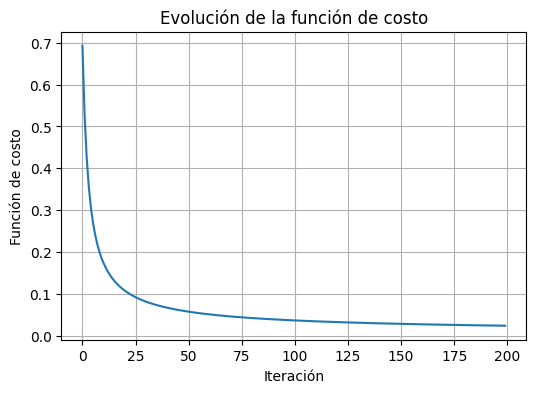

In [9]:

# TODO: graficar la función de costo una vez complete el entrenamiento
plot_loss(loss_history)



## 10. Frontera de decisión

La frontera de decisión ocurre cuando:

$$
\hat{y}=0.5.
$$

Como:

$$
\hat{y}=\sigma(z),
$$

entonces:

$$
\sigma(z)=0.5 \Longleftrightarrow z=0.
$$

Por tanto:

$$
\phi_0+\phi_1 x_1+\phi_2 x_2=0.
$$

Despejando:

$$
x_2=-\frac{\phi_0+\phi_1 x_1}{\phi_2}.
$$


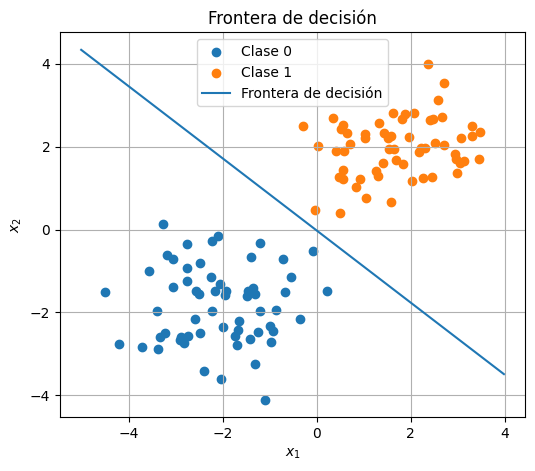

In [10]:

# TODO: completar la gráfica de la frontera de decisión

plt.figure(figsize=(6, 5))
plt.scatter(X[y == 0, 0], X[y == 0, 1], label="Clase 0")
plt.scatter(X[y == 1, 0], X[y == 1, 1], label="Clase 1")

# Valores para x_1
x1_vals = torch.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 100)

# TODO: calcular x2_vals usando los parámetros entrenados
with torch.no_grad():
    x2_vals = -(phi_0 + phi_1 * x1_vals) / phi_2

# TODO: graficar la frontera
plt.plot(x1_vals.numpy(), x2_vals.numpy(), label="Frontera de decisión")

plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.title("Frontera de decisión")
plt.grid(True)
plt.legend()
plt.show()



## 11. Accuracy

Calcule las clases predichas usando el umbral:

$$
\hat{c}=1 \quad \text{si} \quad \hat{y}\geq 0.5.
$$

Luego calcule:

$$
\text{accuracy}
=
\frac{\text{número de aciertos}}{\text{número total de muestras}}.
$$


In [11]:

# TODO: calcular probabilidades finales
z = phi_0 + phi_1 * X[:, 0] + phi_2 * X[:, 1]
y_hat = torch.sigmoid(z)

# TODO: convertir probabilidades en etiquetas
y_pred = (y_hat >= 0.5).float()

# TODO: calcular accuracy
accuracy = (y_pred == y).float().mean()

# TODO: imprimir accuracy
print("Accuracy:", accuracy.item())


Accuracy: 1.0



## 12. Preguntas conceptuales

Responda en celdas Markdown:

1. ¿Qué significa `requires_grad=True`?
   - Significa que PyTorch calcula los gradientes automáticamente durante la retropropagación.
2. ¿Qué calcula `loss.backward()`?
   - Calcula los gradientes de la función de pérdida.
3. ¿Por qué se usa `torch.no_grad()` al actualizar los parámetros?
   - Se usa para desactivar el cálculo de gradientes durante la actualización de los parámetros, evitando que se acumulen gradientes innecesarios.
4. ¿Por qué la frontera de decisión corresponde a $\hat{y}=0.5$?
   - Porque en regresión logística, $\hat{y}=0.5$ es el punto donde la probabilidad de pertenecer a cada clase es igual.
5. ¿Qué relación existe entre entropía cruzada, probabilidad y frontera de decisión?
   - La entropía cruzada mide la discrepancia entre las probabilidades predichas y las etiquetas reales, y la frontera de decisión se define donde la probabilidad predicha es 0.5.
6. ¿Qué ocurre si el factor de aprendizaje $\eta$ es demasiado grande?
   - Puede causar que el modelo no converja y que los parámetros oscilen o diverjan.


## Entregable

Entregar el notebook completado con:

- entrenamiento funcional;
- gráfica de la función de costo;
- gráfica de frontera de decisión;
- accuracy;
- respuestas conceptuales.
